Before Cleaning
Users : 5
Pages : 5

After Cleaning
Users : 3
Pages : 4

----- PROJECT REPORT -----
Total Active Users : 3
Total Unique Pages : 4
Average Friends Per User : 1.33
Most Connected User : Amit
Maximum Friends : 2

----- INSIGHTS -----
Amit is the most connected user with 2 friends.
The network contains 3 active users.
There are 4 unique community pages.
Users have an average of 1.33 friends.


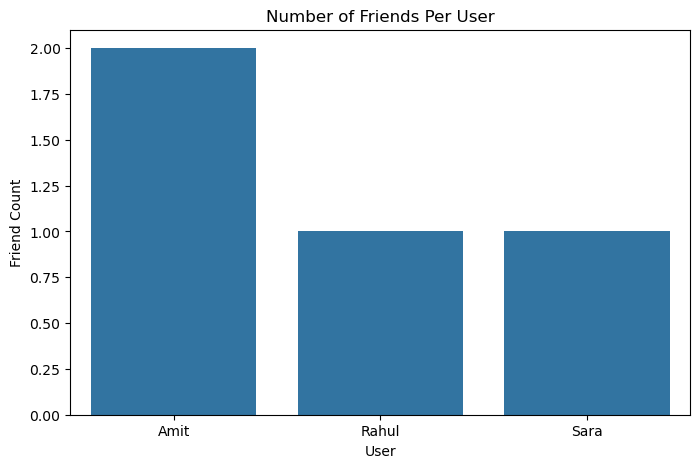

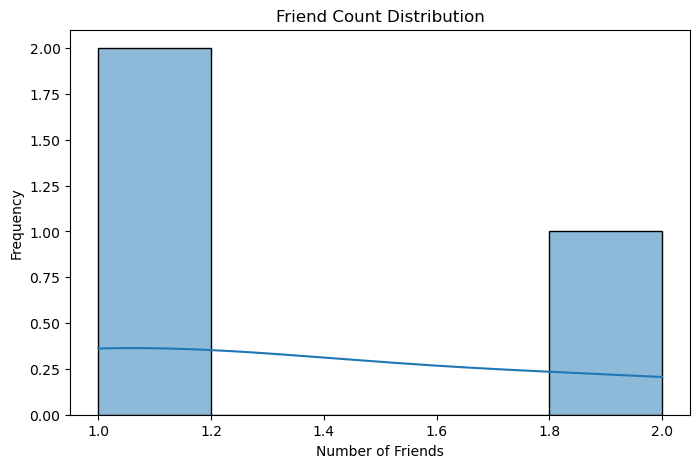

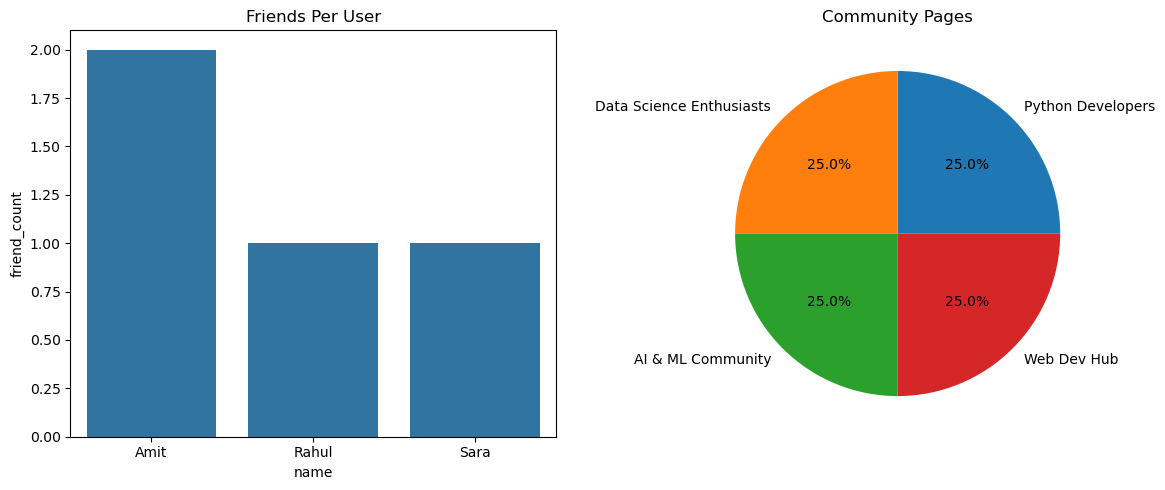

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------
# RAW DATASET
# ----------------------------------

data = {
    "users": [
        {"id": 1, "name": "Amit", "friends": [2, 3, 3], "liked_pages": [101]},
        {"id": 2, "name": "", "friends": [1, 4], "liked_pages": [102]},
        {"id": 3, "name": "Rahul", "friends": [1], "liked_pages": [101, 103]},
        {"id": 4, "name": "Sara", "friends": [2], "liked_pages": [104]},
        {"id": 5, "name": "Outlier", "friends": list(range(1, 150)), "liked_pages": []}
    ],

    "pages": [
        {"id": 101, "name": "Python Developers"},
        {"id": 102, "name": "Data Science Enthusiasts"},
        {"id": 102, "name": "Data Science Enthusiasts"},
        {"id": 103, "name": "AI & ML Community"},
        {"id": 104, "name": "Web Dev Hub"}
    ]
}

# ----------------------------------
# CREATE DATAFRAMES
# ----------------------------------

users_df = pd.DataFrame(data["users"])
pages_df = pd.DataFrame(data["pages"])

print("Before Cleaning")
print("Users :", len(users_df))
print("Pages :", len(pages_df))

# ----------------------------------
# HANDLE MISSING VALUES
# ----------------------------------

users_df["name"] = users_df["name"].fillna("Unknown")

users_df = users_df[
    users_df["name"].str.strip() != ""
]

# ----------------------------------
# REMOVE DUPLICATE FRIENDS
# ----------------------------------

users_df["friends"] = users_df["friends"].apply(
    lambda x: list(set(x))
)

# ----------------------------------
# REMOVE DUPLICATE PAGES
# ----------------------------------

pages_df.drop_duplicates(
    subset="id",
    inplace=True
)

# ----------------------------------
# CREATE FRIEND COUNT
# ----------------------------------

users_df["friend_count"] = users_df["friends"].apply(len)

# ----------------------------------
# HANDLE OUTLIERS
# ----------------------------------

users_df = users_df[
    users_df["friend_count"] <= 100
]

print("\nAfter Cleaning")
print("Users :", len(users_df))
print("Pages :", len(pages_df))

# ----------------------------------
# DATA ANALYSIS
# ----------------------------------

total_users = len(users_df)

total_pages = len(pages_df)

average_friends = users_df["friend_count"].mean()

most_connected_user = users_df.loc[
    users_df["friend_count"].idxmax()
]

print("\n----- PROJECT REPORT -----")

print("Total Active Users :", total_users)

print("Total Unique Pages :", total_pages)

print("Average Friends Per User :",
      round(average_friends, 2))

print("Most Connected User :",
      most_connected_user["name"])

print("Maximum Friends :",
      most_connected_user["friend_count"])

# ----------------------------------
# DATA STORYTELLING
# ----------------------------------

print("\n----- INSIGHTS -----")

print(
    f"{most_connected_user['name']} is the most connected user "
    f"with {most_connected_user['friend_count']} friends."
)

print(
    f"The network contains {total_users} active users."
)

print(
    f"There are {total_pages} unique community pages."
)

print(
    f"Users have an average of "
    f"{round(average_friends,2)} friends."
)

# ----------------------------------
# VISUALIZATION 1
# ----------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    x="name",
    y="friend_count",
    data=users_df
)

plt.title("Number of Friends Per User")
plt.xlabel("User")
plt.ylabel("Friend Count")

plt.show()

# ----------------------------------
# VISUALIZATION 2
# ----------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    users_df["friend_count"],
    bins=5,
    kde=True
)

plt.title("Friend Count Distribution")
plt.xlabel("Number of Friends")
plt.ylabel("Frequency")

plt.show()

# ----------------------------------
# VISUALIZATION 3 (DASHBOARD)
# ----------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(
    x="name",
    y="friend_count",
    data=users_df,
    ax=axes[0]
)

axes[0].set_title("Friends Per User")

page_sizes = [1] * len(pages_df)

axes[1].pie(
    page_sizes,
    labels=pages_df["name"],
    autopct="%1.1f%%"
)

axes[1].set_title("Community Pages")

plt.tight_layout()

plt.show()